In [3]:
# Feline Age Prediction from Spectrograms
!pip install librosa
!pip install tensorflow


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(tf.__version__)

2.21.0


In [5]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path(".").resolve()
EMBEDDINGS_DIR = PROJECT_ROOT / "feline-age-prediction" / "dataset" / "embeddings"

yamnet_path = EMBEDDINGS_DIR / "yamnet_looped_embeddings.csv"
print("YAMNet file exists:", yamnet_path.exists())

orig_embeddings = pd.read_csv(yamnet_path)
orig_embeddings.head()

YAMNet file exists: True


,0,1,2,3,4,5,6,7,8,9,...,1017,1018,1019,1020,1021,1022,1023,gender,target,cat_id
0,0.0,0.000000,1.585768,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,F,6.0,002A
1,0.0,1.304202,2.411754,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,F,10.0,028A
2,0.0,1.128479,0.032892,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,F,3.0,070A
3,0.0,0.069267,0.467173,0.002932,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.359098,0.0,0.0,M,6.0,033A
4,0.0,0.402526,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.268107,0.000000,0.0,0.0,F,2.0,000B


In [6]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path(".").resolve()
RAW_AUDIO_ROOT = PROJECT_ROOT / "feline-age-prediction" / "dataset" / "raw_audio"
print("RAW_AUDIO_ROOT:", RAW_AUDIO_ROOT)

all_files = list(RAW_AUDIO_ROOT.rglob("*.wav"))
print("Found .wav files:", len(all_files))
print("Example:", all_files[0])

rows = []
for p in all_files:
    # Example filename: "0.5Y-022A-F1-01.wav"
    stem = p.stem  # "0.5Y-022A-F1-01"
    first_part = stem.split("-")[0]  # "0.5Y"

    # parse age in years from prefix like "0.5Y", "12Y", etc.
    if first_part.endswith("Y"):
        age_str = first_part[:-1]
        try:
            age = float(age_str)
        except ValueError:
            age = None
    else:
        age = None

    rows.append({"filepath": p, "age": age})

df_meta = pd.DataFrame(rows)
df_meta = df_meta.dropna(subset=["age"]).reset_index(drop=True)

print("df_meta shape:", df_meta.shape)
df_meta.head()

RAW_AUDIO_ROOT: C:\Users\Chenyi\source\repos\deep_purring\feline-age-prediction\dataset\raw_audio
Found .wav files: 3172
Example: C:\Users\Chenyi\source\repos\deep_purring\feline-age-prediction\dataset\raw_audio\AudioCropped\0.5Y-022A-F1-01.wav
df_meta shape: (3172, 2)


,filepath,age
0,C:\Users\Chenyi\source\repos\deep_purring\feli...,0.5
1,C:\Users\Chenyi\source\repos\deep_purring\feli...,0.5
2,C:\Users\Chenyi\source\repos\deep_purring\feli...,0.5
3,C:\Users\Chenyi\source\repos\deep_purring\feli...,0.5
4,C:\Users\Chenyi\source\repos\deep_purring\feli...,0.5


In [7]:
def age_to_age_group(age: float) -> int:
    if age <= 1:
        return 0  # Kitten / young
    elif age <= 10:
        return 1  # Adult / middle
    else:
        return 2  # Senior / old

df_meta["age_group"] = df_meta["age"].apply(age_to_age_group)
df_meta["age_group"].value_counts()

age_group
1    1760
0     752
2     660
Name: count, dtype: int64

In [8]:
all_files = list(RAW_AUDIO_ROOT.rglob("*.wav"))
print("Found .wav files:", len(all_files))
if len(all_files) > 0:
    print("Example:", all_files[0])

Found .wav files: 3172
Example: C:\Users\Chenyi\source\repos\deep_purring\feline-age-prediction\dataset\raw_audio\AudioCropped\0.5Y-022A-F1-01.wav


In [9]:
# Audio / spectrogram params
SAMPLE_RATE = 16000
DURATION = 2.0          # seconds of audio per example (pad/truncate)
N_MELS = 64
HOP_LENGTH = 256
FMIN = 50
FMAX = 8000

# Model / training params
BATCH_SIZE = 32
EPOCHS = 25
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

In [10]:
AGE_GROUP_CATEGORIES = ["Kitten", "Adult", "Senior"]
NUM_CLASSES = len(AGE_GROUP_CATEGORIES)

def age_to_age_group(age: float) -> int:
    if age <= 1:
        return 0      # Kitten
    elif age <= 10:
        return 1      # Adult
    else:
        return 2      # Senior

def fix_embeddings_labels(embeddings: pd.DataFrame, label_col: str) -> pd.DataFrame:
    new_df = embeddings.rename(columns={"target": "age"})
    new_df["age_group"] = new_df["age"].apply(age_to_age_group)

    # keep only numeric feature columns + the label
    new_df = new_df.drop(
        columns=[col for col in new_df.columns if col != label_col and not col.isnumeric()]
    )

    # drop rows with any missing values
    bad = new_df.isna().any(axis=1)
    new_df = new_df[~bad]

    return new_df

fixed_embeddings = fix_embeddings_labels(orig_embeddings, "age_group")
fixed_embeddings.head()

,0,1,2,3,4,5,6,7,8,9,...,1015,1016,1017,1018,1019,1020,1021,1022,1023,age_group
0,0.0,0.000000,1.585768,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,1
1,0.0,1.304202,2.411754,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,1
2,0.0,1.128479,0.032892,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,1
3,0.0,0.069267,0.467173,0.002932,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.359098,0.0,0.0,1
4,0.0,0.402526,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.268107,0.000000,0.0,0.0,1


In [11]:
print("Shape:", fixed_embeddings.shape)

# label distribution
fixed_embeddings["age_group"].value_counts().rename(index={
    0: "Kitten", 1: "Adult", 2: "Senior"
})

Shape: (968, 1025)


age_group
Adult     510
Kitten    248
Senior    210
Name: count, dtype: int64

In [12]:
def load_audio_fixed(path: Path,
                     sample_rate: int = SAMPLE_RATE,
                     duration: float = DURATION) -> np.ndarray:
    target_len = int(sample_rate * duration)
    y, sr = librosa.load(path, sr=sample_rate)

    if len(y) > target_len:
        y = y[:target_len]
    elif len(y) < target_len:
        # pad at end with zeros
        y = np.pad(y, (0, target_len - len(y)), mode="constant")
    return y

def audio_to_mel(y: np.ndarray,
                 sample_rate: int = SAMPLE_RATE,
                 n_mels: int = N_MELS,
                 hop_length: int = HOP_LENGTH,
                 fmin: int = FMIN,
                 fmax: int = FMAX) -> np.ndarray:
    S = librosa.feature.melspectrogram(
        y=y,
        sr=sample_rate,
        n_mels=n_mels,
        hop_length=hop_length,
        fmin=fmin,
        fmax=fmax,
        power=2.0,
    )
    S_db = librosa.power_to_db(S, ref=np.max)
    return S_db



In [13]:
if len(df_meta) == 0:
    raise RuntimeError("df_meta is empty – check FOLDER_TO_GROUP keys vs df_meta['folder'].unique().")

example_path = df_meta["filepath"].iloc[0]
y = load_audio_fixed(example_path)
mel = audio_to_mel(y)

C:\Users\Chenyi\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Wave shape: (32000,)
Mel shape: (64, 126)


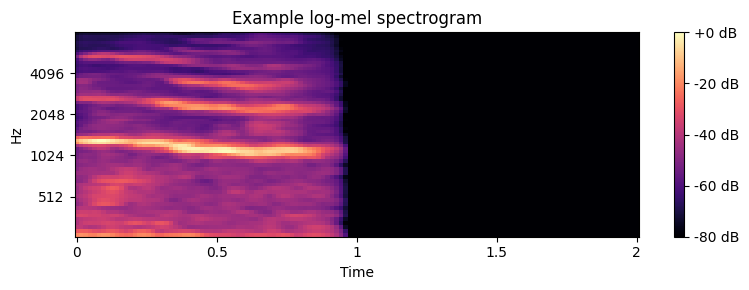

In [14]:
example_path = df_meta["filepath"].iloc[0]
y = load_audio_fixed(example_path)
mel = audio_to_mel(y)
print("Wave shape:", y.shape)
print("Mel shape:", mel.shape)

plt.figure(figsize=(8, 3))
librosa.display.specshow(mel, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                         x_axis="time", y_axis="mel", fmin=FMIN, fmax=FMAX)
plt.colorbar(format="%+2.0f dB")
plt.title("Example log-mel spectrogram")
plt.tight_layout()
plt.show()

In [15]:
def build_spectrogram_dataset(df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    specs = []
    labels = []

    for _, row in df.iterrows():
        y = load_audio_fixed(row["filepath"])
        mel = audio_to_mel(y)
        specs.append(mel)
        labels.append(row["age_group"])

    X = np.stack(specs, axis=0)
    y = np.array(labels, dtype=np.int64)
    return X, y

X, y = build_spectrogram_dataset(df_meta)

print("X shape (before channel):", X.shape)
# add channel dim for CNN: (N, n_mels, time, 1)
X = X[..., np.newaxis]
print("X shape (with channel):", X.shape)
print("y shape:", y.shape)

X shape (before channel): (3172, 64, 126)
X shape (with channel): (3172, 64, 126, 1)
y shape: (3172,)


In [16]:
# train/val/test split with stratification on labels
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=TEST_SPLIT, random_state=SEED, stratify=y
)

val_size_rel = VAL_SPLIT / (1 - TEST_SPLIT)  # relative to remaining data
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_size_rel, random_state=SEED, stratify=y_temp
)

X_train.shape, X_val.shape, X_test.shape

((2220, 64, 126, 1), (476, 64, 126, 1), (476, 64, 126, 1))

In [17]:
input_shape = X_train.shape[1:]
num_classes = 3

def build_cnn_model(input_shape, num_classes: int) -> keras.Model:
    inputs = keras.Input(shape=input_shape)

    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.4)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="feline_age_spectrogram_cnn")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

model = build_cnn_model(input_shape, num_classes)
model.summary()

Model: "feline_age_spectrogram_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 126, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 126, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 126, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 63, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 31, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 31, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 15, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 15, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,467 (431.51 KB)

 Trainable params: 110,019 (429.76 KB)

 Non-trainable params: 448 (1.75 KB)

In [18]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(1024, seed=SEED).batch(BATCH_SIZE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 17s 215ms/step - accuracy: 0.5811 - loss: 0.9339 - val_accuracy: 0.2395 - val_loss: 1.9107 - learning_rate: 0.0010
Epoch 2/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 14s 198ms/step - accuracy: 0.6856 - loss: 0.7505 - val_accuracy: 0.6660 - val_loss: 0.8564 - learning_rate: 0.0010
Epoch 3/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 14s 193ms/step - accuracy: 0.7036 - loss: 0.6927 - val_accuracy: 0.5861 - val_loss: 0.8671 - learning_rate: 0.0010
Epoch 4/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 13s 185ms/step - accuracy: 0.7523 - loss: 0.5960 - val_accuracy: 0.7731 - val_loss: 0.6786 - learning_rate: 0.0010
Epoch 5/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 13s 185ms/step - accuracy: 0.7640 - loss: 0.5546 - val_accuracy: 0.7206 - val_loss: 0.7733 - learning_rate: 0.0010
Epoch 6/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 14s 194ms/step - accuracy: 0.7937 - loss: 0.5213 - val_accuracy: 0.4475 - val_loss: 1.6671 - learning_rate: 0.0010
Epoch 7/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 14s 193ms/step - accuracy: 0.8342 - loss: 0.

In [19]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9433 - loss: 0.1572
Test loss: 0.1572
Test accuracy: 0.9433


In [20]:
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
cm

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
              precision    recall  f1-score   support

           0     0.9722    0.9292    0.9502       113
           1     0.9341    0.9659    0.9497       264
           2     0.9368    0.8990    0.9175        99

    accuracy                         0.9433       476
   macro avg     0.9477    0.9314    0.9392       476
weighted avg     0.9437    0.9433    0.9431       476



array([[105,   8,   0],
       [  3, 255,   6],
       [  0,  10,  89]])

In [21]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


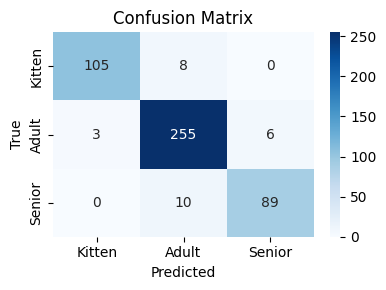

In [22]:
import seaborn as sns

plt.figure(figsize=(4, 3))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Kitten", "Adult", "Senior"],
    yticklabels=["Kitten", "Adult", "Senior"],
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [23]:
# --- Single-audio prediction: run a new meow through the pipeline ---
AGE_GROUP_LABELS = ["Kitten", "Adult", "Senior"]

def predict_age_group(audio_path, model=None):
    """
    Load one audio file, build its spectrogram, and predict age group (Kitten / Adult / Senior).
    Run after training: uses the in-notebook `model` and preprocessing (SAMPLE_RATE, DURATION, etc.).
    audio_path: path to a .wav (or other librosa-supported) file.
    model: optional Keras model; if None, uses the `model` variable from this notebook.
    Returns: (label_str, class_index)
    """
    from pathlib import Path
    audio_path = Path(audio_path)
    if not audio_path.exists():
        raise FileNotFoundError(f"Audio file not found: {audio_path}")

    if model is None:
        model = globals().get("model")
    if model is None:
        raise RuntimeError("No model provided and no trained `model` in notebook. Train the model first.")

    y = load_audio_fixed(audio_path)
    mel = audio_to_mel(y)
    # batch + channel: (1, n_mels, time, 1)
    X = mel[np.newaxis, ..., np.newaxis]

    probs = model.predict(X, verbose=0)
    class_idx = int(np.argmax(probs[0]))
    label = AGE_GROUP_LABELS[class_idx]
    return label, class_idx

# Example (run after training; use your own path for a new file):
# label, idx = predict_age_group("path/to/your/meow.wav")
# print(f"Predicted: {label} (class {idx})")

In [25]:
from pathlib import Path
from tensorflow import keras
# Choose a folder + filename
save_dir = Path("models")
save_dir.mkdir(exist_ok=True)
saved_model_path = save_dir / "cat_spectrogram_cnn.keras"  # or ".h5" if you prefer
model.save(saved_model_path)
print("Saved model to:", saved_model_path)

Saved model to: models\cat_spectrogram_cnn.keras


In [26]:
from tensorflow import keras

saved_model_path = "models/cat_spectrogram_cnn.keras"  # same path as above
saved_model = keras.models.load_model(saved_model_path)

audio_path = r"feline-age-prediction\dataset\raw_audio\AudioCropped\0.5Y-022A-F1-06.wav"
label, idx = predict_age_group(audio_path, model=saved_model)
print(f"Predicted: {label} (class {idx})")

Predicted: Kitten (class 0)
